   horas_aire  recibo
0        15.0   11.22
1        87.0   18.42
2       216.0   42.57
3         6.0   20.76
4        62.0   22.32


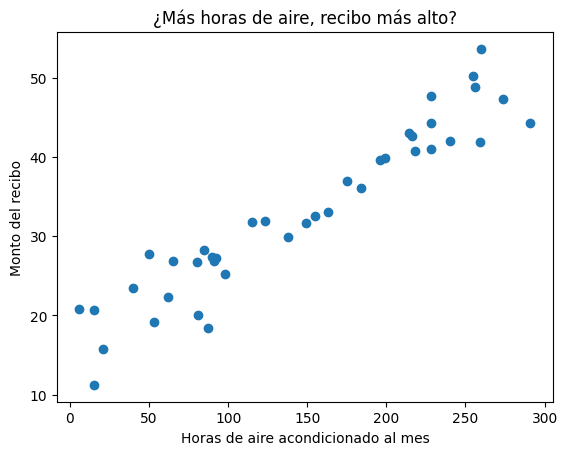

Cargo fijo estimado: 15.75
Costo por hora de aire: 0.119
Regla aprendida: recibo = 15.75 + 0.119 * horas de aire


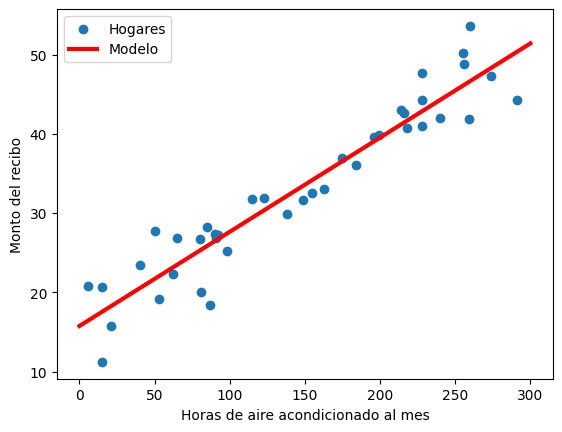

   horas_aire  recibo_estimado
0         250            45.46
1         150            33.58
2          50            21.70
Bajar de 250 a 150 horas ahorraría unos 11.88 al mes


In [ ]:
# Recibo de electricidad Regresion y clasificacion
import numpy as np                                            # numpy: cálculos numéricos y números aleatorios
import pandas as pd                                           # pandas: manejar datos en forma de tabla
import matplotlib.pyplot as plt                               # matplotlib: dibujar gráficos
from sklearn.linear_model import LinearRegression             # el modelo de regresión lineal de scikit-learn

np.random.seed(21)                                            # fija el azar para que todos obtengan los mismos datos
horas_aire = np.random.uniform(0, 300, 40)                    # 40 valores al azar entre 0 y 300 horas de aire al mes
ruido = np.random.normal(0, 4, 40)                            # pequeñas diferencias por otros aparatos (nevera, luces...)
recibo = 15 + 0.12 * horas_aire + ruido                       # regla "real": 15 fijo + 0.12 por hora + el ruido
hogares = pd.DataFrame({"horas_aire": horas_aire.round(0),    # crea la tabla: columna de horas redondeadas
                        "recibo": recibo.round(2)})           # y columna del recibo con 2 decimales
print(hogares.head())                                         # muestra las primeras 5 filas de la tabla

plt.scatter(hogares["horas_aire"], hogares["recibo"])         # grafico de puntos
plt.xlabel("Horas de aire acondicionado al mes")              # titulo del eje horizontal
plt.ylabel("Monto del recibo")                                # titulo del eje vertical
plt.title("¿Más horas de aire, recibo más alto?")             # titulo del grafico
plt.show()                                                    # muestra el grafico en pantalla

#Separar entradas y objetivo

X = hogares[["horas_aire"]] # entradas doble
y = hogares["recibo"]       # objetivo
#Entrenar
modelo = LinearRegression()                                   # crea un modelo de regresión lineal vacío
modelo.fit(X, y)                                              # entrena: busca el punto de partida y la pendiente

#Leer lo que apredio
cargo_fijo = modelo.intercept_                                # punto de partida: recibo estimado con 0 horas de aire
costo_hora = modelo.coef_[0]                                  # pendiente: cuánto sube el recibo por cada hora de aire
print(f"Cargo fijo estimado: {cargo_fijo:.2f}")               # imprime el cargo fijo con 2 decimales
print(f"Costo por hora de aire: {costo_hora:.3f}")            # imprime el costo por hora con 3 decimales
print(f"Regla aprendida: recibo = {cargo_fijo:.2f} + {costo_hora:.3f} * horas de aire") # imprime la fórmula completa

#Dibujar la linea del modelo
rango = pd.DataFrame({"horas_aire": np.linspace(0, 300, 100)})                  # 100 valores de horas entre 0 y 300 para dibujar la línea
plt.scatter(hogares["horas_aire"], hogares["recibo"], label="Hogares")          # puntos reales
plt.plot(rango["horas_aire"], modelo.predict(rango), color="red", linewidth=3, label="Modelo")  # línea roja del modelo
plt.xlabel("Horas de aire acondicionado al mes")                                # título del eje horizontal
plt.ylabel("Monto del recibo")                                                  # título del eje vertical
plt.legend()                                                                    # muestra la leyenda (qué es cada cosa)
plt.show()                                                                      # mestra el gráfico

#Comparar escenarios de ahorro
planes = pd.DataFrame({"horas_aire": [250, 150, 50]})                           # tabla con tres escenarios de uso
planes["recibo_estimado"] = modelo.predict(planes[["horas_aire"]]).round(2)     # recibo que predice el modelo para cada escenario
print(planes)                                                                   # muestra la tabla de escenarios
ahorro = planes["recibo_estimado"].iloc[0] - planes["recibo_estimado"].iloc[1]  # diferencia entre 250 horas (fila 0) y 150 horas (fila 1)
print(f"Bajar de 250 a 150 horas ahorraría unos {ahorro:.2f} al mes")           # imprime el ahorro estimado


In [ ]:
#1. Precio de autos usados (regresion multiple y metricas)
from numpy.random.mtrand import random
import numpy as np                                            # numpy: cálculos numéricos y números aleatorios
import pandas as pd                                           # pandas: manejar datos en forma de tabla
import matplotlib.pyplot as plt                               # matplotlib: dibujar gráficos
from sklearn.linear_model import LinearRegression             # el modelo de regresión lineal de scikit-learn
from sklearn.model_selection import  train_test_split         #Funcion para dividir el entrenamiento y prueba
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score #metricas:error promedio,error cuadratico y R

#2. Crea 250 autos usados
np.random.seed(8)                                                       # fija el azar para que todos obtengan los mismos datos
n = 250                                                                 # cantidad de autos a crear

antiguedad = np.random.randint(1, 16, n)                                # años del auto, entre 1 y 15
kilometraje = np.random.randint(5, 250, n)                              # miles de kilómetros recorridos, entre 5 y 249
motor = np.random.choice([1.2, 1.6, 2.0, 2.5], n)                       # tamaño del motor en litros, elegido de 4 opciones
precio = (18000 - 700 * antiguedad - 25 * kilometraje + 3000 * motor    # regla "real" del precio (valores ilustrativos)
          + np.random.normal(0, 1200, n))                               # más ruido: estado, color, accesorios...


autos = pd.DataFrame({"antiguedad": antiguedad, "kilometraje_miles": kilometraje,  # crea la tabla con las entradas
                        "motor_litros": motor, "precio": precio.round(0)})         # y el precio redondeado

print(autos.head())                                                                # muestra las primeras 5 filas
print(autos.describe().round(1))                                                   # resumen de cada columna: promedio, mínimo, máximo...


#3. Separar y dividir
X = autos[["antiguedad", "kilometraje_miles", "motor_litros"]]                  #Entradas de info
y = autos["precio"]                                                             #Objetivo

X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42) #dividir en entrenamiento y prueba

print("Entrenamiento:", len(X_train), "autos | Prueba:", len(X_test), "autos")  # cuántos autos quedaron en cada grupo

#4. Entrenar
modelo=LinearRegression()                                                       #crea un modelo de regresion linal vacio
modelo.fit(X_train,y_train)                                                     #entrena: bysca un coeficiente para cada caracteristicas

#5. Interpretar cada coeficiente
table= pd.DataFrame({"variable": X.columns,                                   #Tabla con el nombre de cada caracteristica
                     "coeficiente":modelo.coef_.round(1)})                    #y su coeficiente con un decimal


print("Punto de partida: ", round(modelo.intercept_,0))                         #Imprime la tabla de coeficiente
print(table)


#6 Evaluar
y_pred = modelo.predict(X_test)                      # precios estimados para los autos de prueba
mae = mean_absolute_error(y_test, y_pred)            # error promedio en dólares
rmse = np.sqrt(mean_squared_error(y_test, y_pred))   # error que castiga más los fallos grandes
r2 = r2_score(y_test, y_pred)                        # porcentaje de variación explicado (máximo 1)
print(f"Error promedio (MAE): {mae:,.0f} dólares")   # imprime el error promedio
print(f"Error con castigo (RMSE): {rmse:,.0f} dólares")  # imprime el error con castigo
print(f"Porcentaje explicado (R²): {r2:.3f}")        # imprime el R² con 3 decimales

#7
anuncio = pd.DataFrame({"antiguedad": [6], "kilometraje_miles": [90], "motor_litros": [1.6]})  # auto del anuncio
estimado = modelo.predict(anuncio)[0]                # precio que estima el modelo
pedido = 19000                                       # precio que pide el vendedor
print(f"Precio estimado por el modelo: {estimado:,.0f} dólares")      # imprime el precio estimado
print(f"Diferencia con lo que piden: {pedido - estimado:,.0f} dólares")  # imprime cuánto más (o menos) piden


   antiguedad  kilometraje_miles  motor_litros   precio
0           4                 81           1.2  13878.0
1           5                 90           1.2  16700.0
2           2                166           2.0  18756.0
3          10                 70           2.0  14429.0
4           6                203           2.0  16102.0
       antiguedad  kilometraje_miles  motor_litros   precio
count       250.0              250.0         250.0    250.0
mean          8.2              128.3           1.9  14784.9
std           4.2               71.5           0.5   3901.6
min           1.0                6.0           1.2   4152.0
25%           4.0               70.0           1.6  11715.8
50%           8.0              129.0           2.0  14753.0
75%          12.0              193.5           2.5  17614.0
max          15.0              248.0           2.5  23755.0
Entrenamiento: 200 autos | Prueba: 50 autos
Punto de partida:  17913.0
            variable  coeficiente
0         antigueda